# Notebook 02_EDA_visual_analysis

## Introducción e Hipótesis
El Análisis Exploratorio de Datos (EDA) en este estudio es un proceso de validación y detección de anomalías. 
Buscamos determinar si el Bitcoin opera bajo una lógica de activo refugio o si su comportamiento lo sitúa como un activo de riesgo extremo vinculado a la liquidez global.

**Hipótesis:** El Bitcoin actúa como un activo de **'Beta elevado'** respecto al sector tecnológico, mostrando así una dependencia estructural con el NASDAQ que se ve amplificada por los ciclos de liquidez de la FED.

In [1]:
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de ruta para acceder a la carpeta /src
sys.path.append(os.path.abspath(os.path.join('..')))

# Importamos las funciones de análisis y visualización
from src.descriptive_analysis import get_descriptive_stats
from src.data_visualization import (
    plot_comparative_growth, 
    plot_correlation_heatmap, 
    plot_scatter_btc_analysis
)

# Configuramos un estilo visual para las visualizaciones
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("tab10")

print("✅ Módulos de análisis y visualización cargados.")

✅ Módulos de análisis y visualización cargados.


In [2]:
data_path = os.path.join('..', 'data', 'bitcoin_nasdaq_extended_py.csv')

df_clean = pd.read_csv(data_path, index_col='Date', parse_dates=True)

print(f"✅ Dataset cargado. Rango temporal: {df_clean.index.min()} a {df_clean.index.max()}")

✅ Dataset cargado. Rango temporal: 2015-01-31 00:00:00 a 2025-02-28 00:00:00


## 1. Análisis de Momentos y Perfil de Riesgo
Más allá de la media, evaluamos la **asimetría ($Skewness$)** y la **curtosis ($Kurtosis$)** para identificar la naturaleza de la distribución de los activos bajo estudio. En finanzas, estas métricas son los primeros indicadores que muestran la presencia de eventos extremos o 'colas pesadas'.

In [3]:
# Ejecución de estadísticos descriptivos
stats = get_descriptive_stats(df_clean)

print("--- Resumen Estadístico (Incluyendo Skewness y Kurtosis) ---")
stats

--- Resumen Estadístico (Incluyendo Skewness y Kurtosis) ---


,mean,std,min,50%,max,skew,kurtosis
btc,21650.43,24254.86,217.46,10153.36,102405.02,1.32,1.10
nasdaq,10045.77,4277.36,4557.95,8777.51,19627.44,0.46,-0.96
btc_vol,0.63,0.30,0.22,0.56,1.96,1.49,3.37
fed_rate,1.82,1.89,0.05,1.16,5.33,0.85,-0.76


### Hallazgos en los Datos:
* **Exceso de Dispersión**: La desviación estándar del BTC ($\sigma \approx 24,254$) supera a su media ($\mu \approx 21,650$). Empíricamente, esto corrobora que el Bitcoin es un activo cuya rentabilidad esperada está intrínsecamente ligada a una volatilidad masiva, alejándolo de la estabilidad de activos defensivos como el oro.
* **Leptocurtosis y Colas Pesadas**: El valor de la curtosis en `btc_vol` ($3.37$) es superior a 3 (distribución normal). Esto es evidencia empírica de 'Fat Tails'; el mercado de criptoactivos experimenta "shocks" de volatilidad extrema con una frecuencia mucho mayor de la que predeciría un modelo estándar, lo que anticipa fallos en modelos lineales simples.
* **Sesgo Positivo ($Skewness$ = 1.32)**: La distribución del BTC está sesgada a la derecha. Esto refleja una asimetría típica de activos en fase de adopción exponencial: Es decir, a pesar de que sufra caídas violentas, la magnitud de los movimientos alcistas estructurales del activo dominan la serie histórica.

## 2. Dinámica de Precios: El Papel de la Escala Logarítmica
Para comparar activos con precios tan dispares (NASDAQ y  BTC), normalizamos ambas series a **Base 100** (Enero 2015).

### Interpretación del Rendimiento Relativo
Dado que el Bitcoin crece en órdenes de magnitud (de $\$300$ a $\$100,000+$), la escala lineal "aplastaría" visualmente al NASDAQ (haciendo que sea vea aplanado), impidiendo así un análisis de variabilidad conjunto. 
* **!! Escala Logarítmica**: Es la herramienta estándar para activos con crecimiento compuesto. Nos permite visualizar los **rendimientos porcentuales relativos**: un movimiento del $10\%$ se ve igual independientemente de si el precio es $\$1,000$ o $\$100,000$.
* **Hallazgo**: El gráfico revela que el BTC no solo sigue la dirección del NASDAQ, sino que actúa como un amplificador de su tendencia, provocando así una sensibilidad mayor a eventos que el NASDAQ.

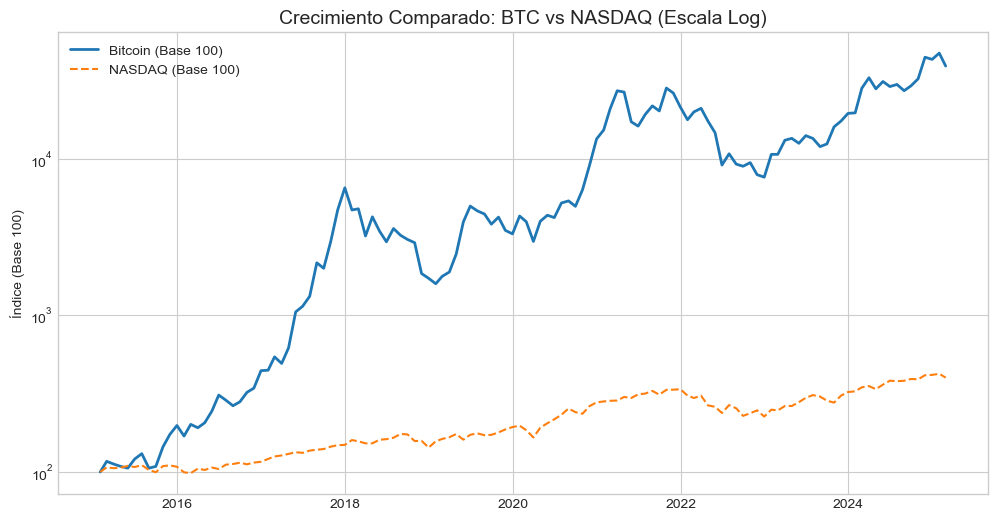

In [4]:
# Gráfico de Base 100 en escala logarítmica
plot_comparative_growth(df_clean)

## 3. Estructura de Correlaciones
Calculamos la correlación de Pearson para cuantificar la fuerza de la relación lineal. 

> **⚠️ Advertencia sobre la Regresión Espuria**: Una correlación extremadamente alta entre series temporales con tendencias alcistas potentes (como el $0.94$ observado aquí) puede ser engañosa. Dos variables pueden parecer vinculadas simplemente porque ambas crecen con el tiempo ($Non-stationarity$). En ese caso, se deberá de proceder a realizar un test de raíz unitaria.

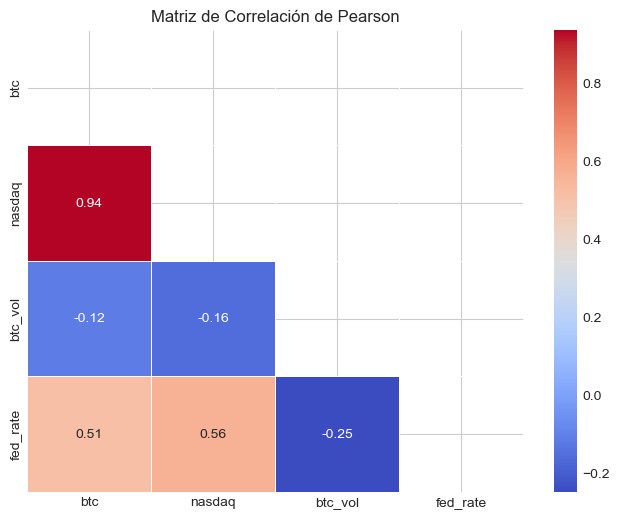

In [5]:
# Mapa de calor de la matriz de correlación
plot_correlation_heatmap(df_clean)

### Análisis de los hallazgos del Coeficiente de Pearson ($r$):
* **Sintonía Extrema ($0.94$)**: El mercado trata al Bitcoin como un activo **'Risk-on'** al igual que con el activo NASDAQ. Esta correlación invalida empíricamente la narrativa viralizada del BTC como 'oro digital' descorrelacionado para este periodo (2015-2025); Es decir, se comporta como un satélite del sector tecnológico estadounidense.
* **La Paradoja de la FED ($0.51$)**: Sorprendentemente, existe una correlación positiva moderada con la tasa FED. Esto sugiere que, históricamente, la maduración del ecosistema cripto y la adopción institucional han tenido un peso mayor en el precio del activo que la puesta en marcha de diversas politicas monetarias por parte de la FED.

## 4. Análisis de Dispersión y Heterocedasticidad
Buscamos identificar si la relación entre las variables es constante o si cambia según el nivel de precios.

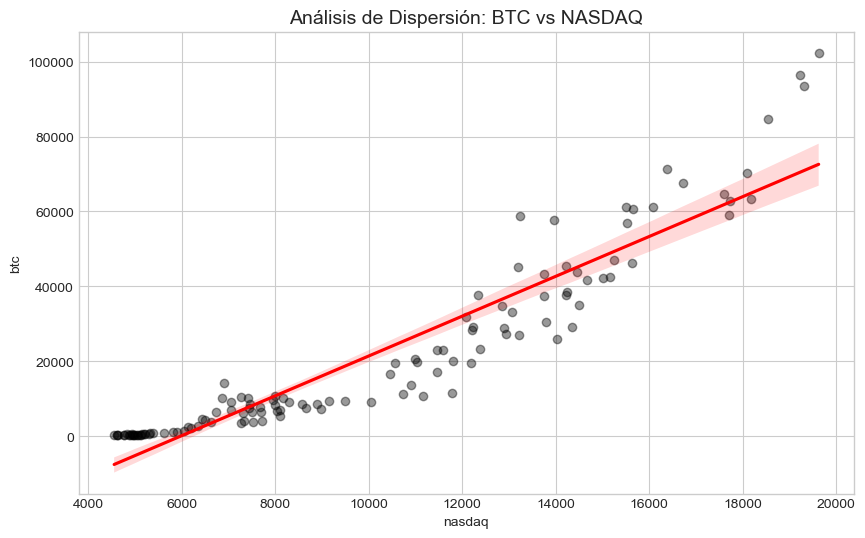

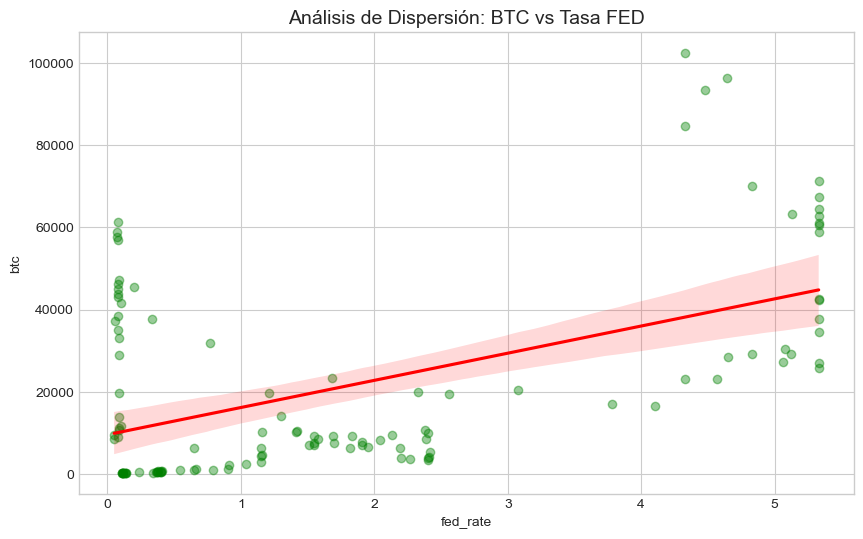

In [6]:
# 1. BTC vs NASDAQ 
plot_scatter_btc_analysis(df_clean, 'nasdaq', 'Análisis de Dispersión: BTC vs NASDAQ', 'black')

# 2. BTC vs Tasa FED
plot_scatter_btc_analysis(df_clean, 'fed_rate', 'Análisis de Dispersión: BTC vs Tasa FED', 'green')

## Observaciones y Hallazgos

Tras completar el Análisis Exploratorio, extraemos las siguientes conclusiones críticas que marcarán la hoja de ruta de la modelización:

### 1. Perfil de Riesgo y No-Normalidad
El contraste estructural entre activos es evidente. El NASDAQ presenta una variabilidad moderada, mientras que el Bitcoin exhibe un **exceso de variabilidad** donde la desviación estándar supera ampliamente a la media. 
* **Hallazgo**: La curtosis de la volatilidad de BTC ($3.37$) confirma una distribución **leptocúrtica**. En el sector financiero, esto se traduce en la presencia de 'Fat Tails' (colas pesadas), indicando que los movimientos extremos del mercado ocurren con una frecuencia mucho mayor de la que predeciría una distribución normal (Gauss).

### 2. Sincronía con el Sector Tecnológico (High-Beta Asset)
La correlación de $0.94$ y el análisis de crecimiento en base 100 confirman que el Bitcoin ha completado su transición hacia un activo **'Risk-on'**. 
* **Interpretación**: No se observa un comportamiento de activo refugio; empíricamente, el Bitcoin actúa como un **"Nasdaq apalancado"** o un activo de **Beta elevado**, no como un activo refugio. Esto significa que amplifica los ciclos de euforia en el sector tecnológico, pero también las fases de corrección sistémica como 'Black Swings'.

### 3. La 'contradicción' de la Política Monetaria
A pesar de que el endurecimiento monetario de la FED suele drenar la liquidez de activos especulativos, el Bitcoin ha mostrado una **resiliencia inesperada** en niveles de tipos superiores al $5\%$ (según el periódo que estamos estudiando).
* **Hallazgo**: Esto sugiere que factores de adopción institucional y shocks de oferta endógenos (como el *halving* de BTC) han tenido, en periodos específicos, mayor peso que el coste del dinero (designado a traves de las politicas monetarias de la FED).

### 4. Diagnóstico de Inestabilidad 
La inspección visual de los diagramas de dispersión revela **heterocedasticidad** (la varianza no es constante a medida que sube el precio de los activos. 
* **Implicación**: Este hallazgo es una señal de alerta: Es decir, un modelo lineal estático (OLS) será ineficiente y sesgado. Por otro lado, la fuerte inercia de las series anticipa, además, problemas de **autocorrelación** (memoria del mercado).

## Conclusiones del EDA y Próximos Pasos

En resumen, el análisis exploratorio revela series con tendencias estocásticas notorias y una volatilidad condicional variable. 

**Veredicto Metodológico:**
La alta correlación lineal observada y la complejidad de la relación con la tasa FED indican que un modelo de regresión lineal simple (OLS) sería ineficiente y propenso a errores de **regresión espuria** al incumplirse propiedades indispensables.

**¿Qué haremos a continuación?**
Para garantizar la robustez de la investigación, en el **Notebook_03** aplicaremos:
1. **Tests de Raíz Unitaria (ADF/KPSS)** para confirmar matemáticamente la no-estacionariedad de las series.
2. **Estimación de un modelo OLS ineficaz** con el objetivo de demostrar empíricamente cómo fallan los supuestos clave (Normalidad, Homocedasticidad y Autocorrelación) y justificar la necesidad de modelos econométricos avanzados.